[[ 60.  34.  40.  35.  45.  21.  25.  40.  26.  36.  39.  42.  26.  50.
   34.  30.  36.  45.  50.  50.  46.  50.  33.  38.  50.  35.  40.  48.
   17.  19.  10.  11.  12.   5.   9.]
 [168. 170. 179. 173. 148. 167. 175. 145. 165. 170. 157. 167. 168. 163.
  164. 178. 179. 169. 166. 157. 155. 145. 178. 158. 155. 146. 180. 165.
  183. 170. 150. 138. 154. 111. 143.]
 [ 52.  47.  44.  46.  38.  45.  43.  37.  37.  48.  42.  48.  46.  38.
   48.  51.  44.  43.  47.  42.  41.  40.  47.  40.  40.  40.  50.  46.
   49.  52.  39.  38.  39.  28.  35.]]
[[ 26.08571429   0.08571429   6.08571429   1.08571429  11.08571429
  -12.91428571  -8.91428571   6.08571429  -7.91428571   2.08571429
    5.08571429   8.08571429  -7.91428571  16.08571429   0.08571429
   -3.91428571   2.08571429  11.08571429  16.08571429  16.08571429
   12.08571429  16.08571429  -0.91428571   4.08571429  16.08571429
    1.08571429   6.08571429  14.08571429 -16.91428571 -14.91428571
  -23.91428571 -22.91428571 -21.91428571 -28.914285

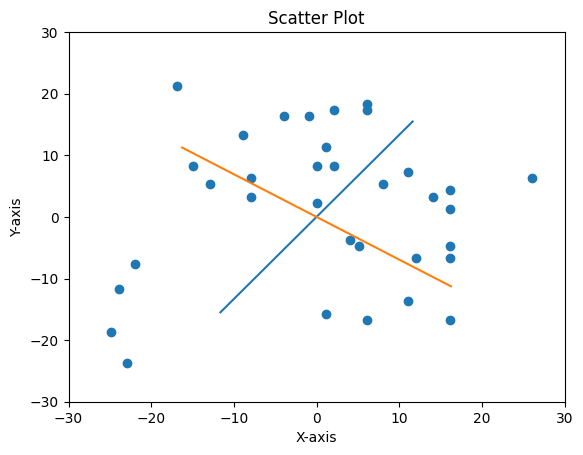

In [58]:
import numpy as np
import math
import pandas as pd
import  matplotlib.pyplot as plt

def find_col_norm(V, pos, n):
    s = 0.0
    for i in range(n):
        s += V[i][pos] * V[i][pos]
    return math.sqrt(s)

def find_vec_norm(V, n):
    s = 0.0
    for i in range(n):
        s += V[i] * V[i]
    return math.sqrt(s)

def find_dot_vec(A, B, n):
    s = 0.0
    for i in range(n):
        s += A[i] * B[i]
    return s

def find_transpose(A, n, m):
    Atrp = np.zeros((m, n))
    for i in range(n):
        for j in range(m):
            Atrp[j][i] = A[i][j]
    return Atrp

def matrix_multiply(A1, A2, n, t, m):
    Ares = np.zeros((n, m))
    for i in range(n):
        for j in range(m):
            for k in range(t):
                Ares[i][j] += A1[i][k] * A2[k][j]
    return Ares

def uv_prod(U, V, n, m):
    res = np.zeros((n, m))
    for i in range(n):
        for j in range(m):
            res[i][j] = U[i] * V[j]
    return res

def matrix_sum(A, B, n, m):
    res = np.zeros((n, m))
    for i in range(n):
        for j in range(m):
            res[i][j] = A[i][j] + B[i][j]
    return res

def mean_center(A):
  n,m = A.shape
  Ares = np.zeros((n, m))
  if n > m:
   for j in range(m):
        sum = 0.0
        for i in range(n):
            sum += A[i][j]
        mean = sum/n
        for i in range(n):
            Ares[i][j] = A[i][j]-mean
  else:
      for i in range(n):
        sum = 0.0
        for j in range(m):
            sum += A[i][j]
        mean = sum/m
        for j in range(m):
             Ares[i][j] = A[i][j]-mean
  return Ares

def mp_scalar(A,const):
 n,m = A.shape
 Ares = np.zeros((n, m))
 for i in range(n):
    for j in range(m):
      Ares[i][j] = A[i][j]*const
 return Ares

'''
n = int(input("Enter number of rows: "))
m = int(input("Enter number of columns: "))

A = np.zeros((n, m))
for i in range(n):
    for j in range(m):
        A[i][j] = float(input("Enter the element A[{}][{}]: ".format(i, j)))'''

path = "/rwld_dataset_3D.xlsx"
df = pd.read_excel(path)
mat = df.to_numpy()
n,m = mat.shape

A = np.zeros((m, n))
for i in range(n):
  for j in range(m):
    A[j][i] = mat[i][j]

print(A)

A = mean_center(A)
print(A)
n,m = A.shape

eps = 1e-12

if n >= m:
    Atrp = find_transpose(A, n, m)
    A_tmp = matrix_multiply(Atrp, A, m, n, m)
    N = m

    print(n)

    A_curr = mp_scalar(A_tmp, 1.0/(n-1))

    print('\nVariance covariance matrix: -')
    print(A_curr)

    Q_final = np.eye(N)

    for _ in range(30):
        Q = np.zeros((N, N))
        R = np.zeros((N, N))

        for j in range(N):
            v = np.zeros(N)
            for i in range(N):
                v[i] = A_curr[i][j]

            for i in range(j):
                qi = np.zeros(N)
                for k in range(N):
                    qi[k] = Q[k][i]
                R[i][j] = find_dot_vec(qi, A_curr[:, j], N)
                for k in range(N):
                    v[k] -= R[i][j] * qi[k]

            R[j][j] = find_vec_norm(v, N)
            if R[j][j] < eps:
                continue

            for k in range(N):
                Q[k][j] = v[k] / R[j][j]

        A_curr = matrix_multiply(R, Q, N, N, N)
        Q_final = matrix_multiply(Q_final, Q, N, N, N)

    V = Q_final
    sigma = np.zeros((N, N))
    sigma_inv = np.zeros((N, N))

    for i in range(N):
        val = A_curr[i][i]
        if val < 0:
            val = 0
        sigma[i][i] = math.sqrt(val)
        if sigma[i][i] > eps:
            sigma_inv[i][i] = 1.0 / sigma[i][i]

    AV = matrix_multiply(A, V, n, m, N)
    U = matrix_multiply(AV, sigma_inv, n, N, N)

    for j in range(N):
        norm = find_col_norm(U, j, n)
        if norm > eps:
            for i in range(n):
                U[i][j] /= norm

else:
    Atrp = find_transpose(A, n, m)
    A_tmp = matrix_multiply(A, Atrp, n, m, n)
    N = n

    print(m)
    A_curr = mp_scalar(A_tmp, 1.0/(m-1))

    print('\nVariance covariance matrix: -')
    print(A_curr)

    Q_final = np.eye(N)

    for _ in range(30):
        Q = np.zeros((N, N))
        R = np.zeros((N, N))

        for j in range(N):
            v = np.zeros(N)
            for i in range(N):
                v[i] = A_curr[i][j]

            for i in range(j):
                qi = np.zeros(N)
                for k in range(N):
                    qi[k] = Q[k][i]
                R[i][j] = find_dot_vec(qi, A_curr[:, j], N)
                for k in range(N):
                    v[k] -= R[i][j] * qi[k]

            R[j][j] = find_vec_norm(v, N)
            if R[j][j] < eps:
                continue

            for k in range(N):
                Q[k][j] = v[k] / R[j][j]

        A_curr = matrix_multiply(R, Q, N, N, N)
        Q_final = matrix_multiply(Q_final, Q, N, N, N)

    U = Q_final
    sigma = np.zeros((N, N))
    sigma_inv = np.zeros((N, N))

    for i in range(N):
        val = A_curr[i][i]
        if val < 0:
            val = 0
        sigma[i][i] = math.sqrt(val)
        if sigma[i][i] > eps:
            sigma_inv[i][i] = 1.0 / sigma[i][i]

    Ut = find_transpose(U, N, N)
    UtA = matrix_multiply(Ut, A, N, n, m)
    Vt = matrix_multiply(sigma_inv, UtA, N, N, m)
    V = find_transpose(Vt, N, m)

k = int(input("Enter k for truncated summation: "))
k = min(k, min(n, m))

A_k = np.zeros((n, m))
for i in range(k):
    uv = uv_prod(U[:, i], V[:, i], n, m)
    for r in range(n):
        for c in range(m):
            uv[r][c] *= sigma[i][i]
    A_k = matrix_sum(A_k, uv, n, m)

print("\nU =")
print(U)

print("\nSigma =")
print(sigma)

print("\nV =")
print(V)

print("\nReconstructed A using k terms =")
print(A_k)

sf = 20
plt.scatter(A[0,:],A[1,:])
plt.plot([-sf*U[0][0],sf*U[0][0]],[-sf*U[1][0],sf*U[1][0]])
plt.plot([-sf*U[0][1],sf*U[0][1]],[-sf*U[1][1],sf*U[1][1]])
plt.xlabel('X-axis')
plt.xlim(-30,30)
plt.ylim(-30,30)
plt.ylabel('Y-axis')
plt.title('Scatter Plot')
plt.show()
